## Dataset and Libraries


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, classification_report)
from sklearn.cluster import KMeans


In [7]:
df = pd.read_csv("data/heart_disease.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Dataset Description

###Basic info, data types, and missing values

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


### Features count

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Input Features:", df.shape[1]-1)
print()
print("Target variable 'num' value counts (0 = no disease, 1-4 = increasing severity):")
print(df['num'].value_counts().sort_index())

Number of rows: 920
Number of columns: 16
Input Features: 15

Target variable 'num' value counts (0 = no disease, 1-4 = increasing severity):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


### Categorical features count

In [10]:
categorical_features = df.select_dtypes(include=["object"]).columns
print("Categorical features:")
print(categorical_features.tolist())
for column in categorical_features:
    print("\n", column)
    print(df[column].value_counts(dropna=False))

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

 sex
sex
Male      726
Female    194
Name: count, dtype: int64

 dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

 cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

 fbs
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

 restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

 exang
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

 slope
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

 thal
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_7184\2330429849.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns


###Imbalanced dataset check

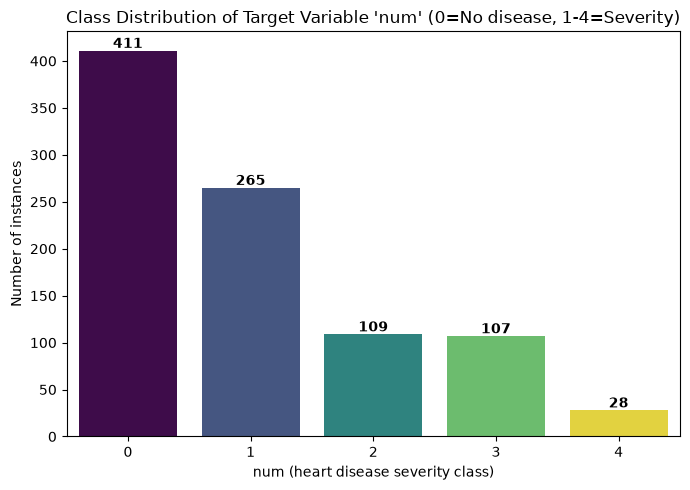

In [11]:
plt.figure(figsize=(7, 5))
counts = df['num'].value_counts().sort_index()
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.xlabel("num (heart disease severity class)")
plt.ylabel("Number of instances")
plt.title("Class Distribution of Target Variable 'num' (0=No disease, 1-4=Severity)")
plt.tight_layout()
plt.show()

target
1    509
0    411
Name: count, dtype: int64


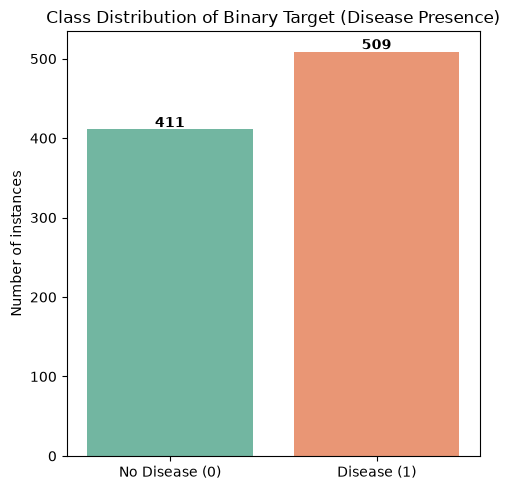

In [12]:
df['target'] = (df['num'] > 0).astype(int)
print(df['target'].value_counts())

plt.figure(figsize=(5, 5))
counts_b = df['target'].value_counts().sort_index()
ax = sns.barplot(x=['No Disease (0)', 'Disease (1)'], y=counts_b.values,
                  hue=['No Disease (0)', 'Disease (1)'], palette="Set2", legend=False)
for i, v in enumerate(counts_b.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.ylabel("Number of instances")
plt.title("Class Distribution of Binary Target (Disease Presence)")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis(EDA)

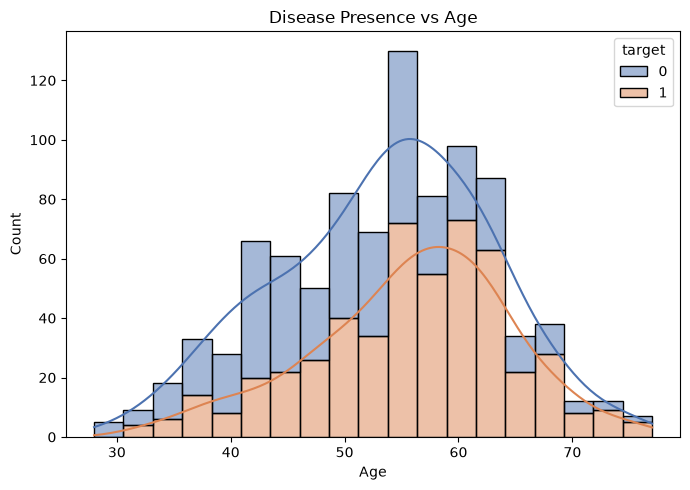

In [13]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette=['#4C72B0', '#DD8452'], multiple='stack')
plt.title("Disease Presence vs Age")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

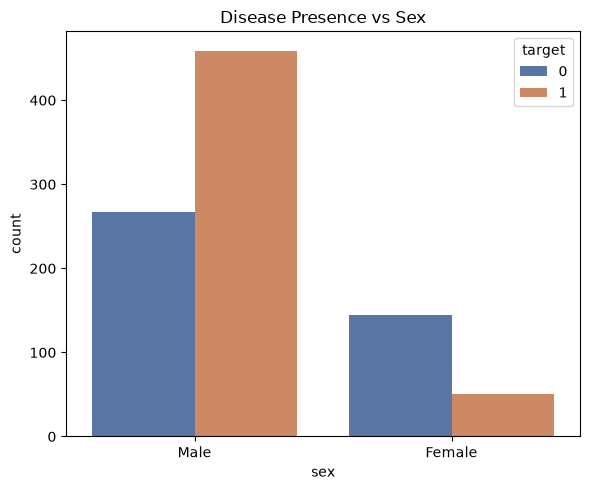

In [14]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='sex', hue='target', palette=['#4C72B0', '#DD8452'])
plt.title("Disease Presence vs Sex")
plt.tight_layout()
plt.show()

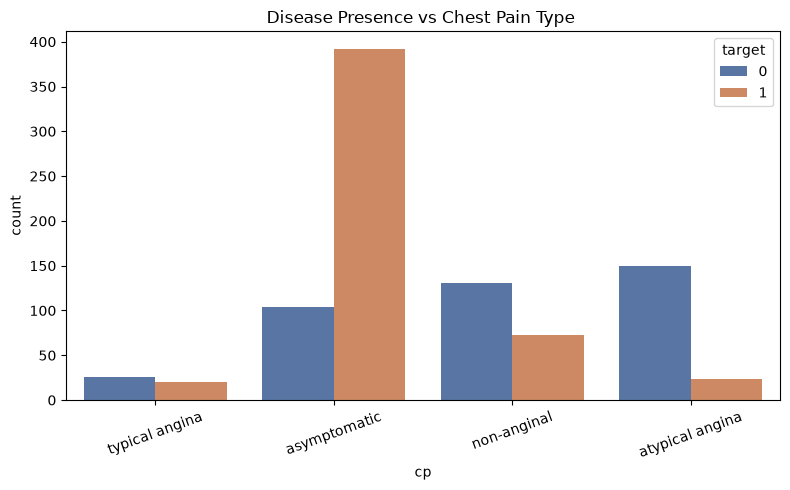

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cp', hue='target', palette=['#4C72B0', '#DD8452'])
plt.title("Disease Presence vs Chest Pain Type ")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Fault Check

### Missing Value count and percentage

In [16]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
id,0,0.000000
age,0,0.000000
sex,0,0.000000
dataset,0,0.000000
cp,0,0.000000
trestbps,59,6.413043
chol,30,3.260870
fbs,90,9.782609
restecg,2,0.217391
thalch,55,5.978261


### Numerical Features' Scales

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'target']


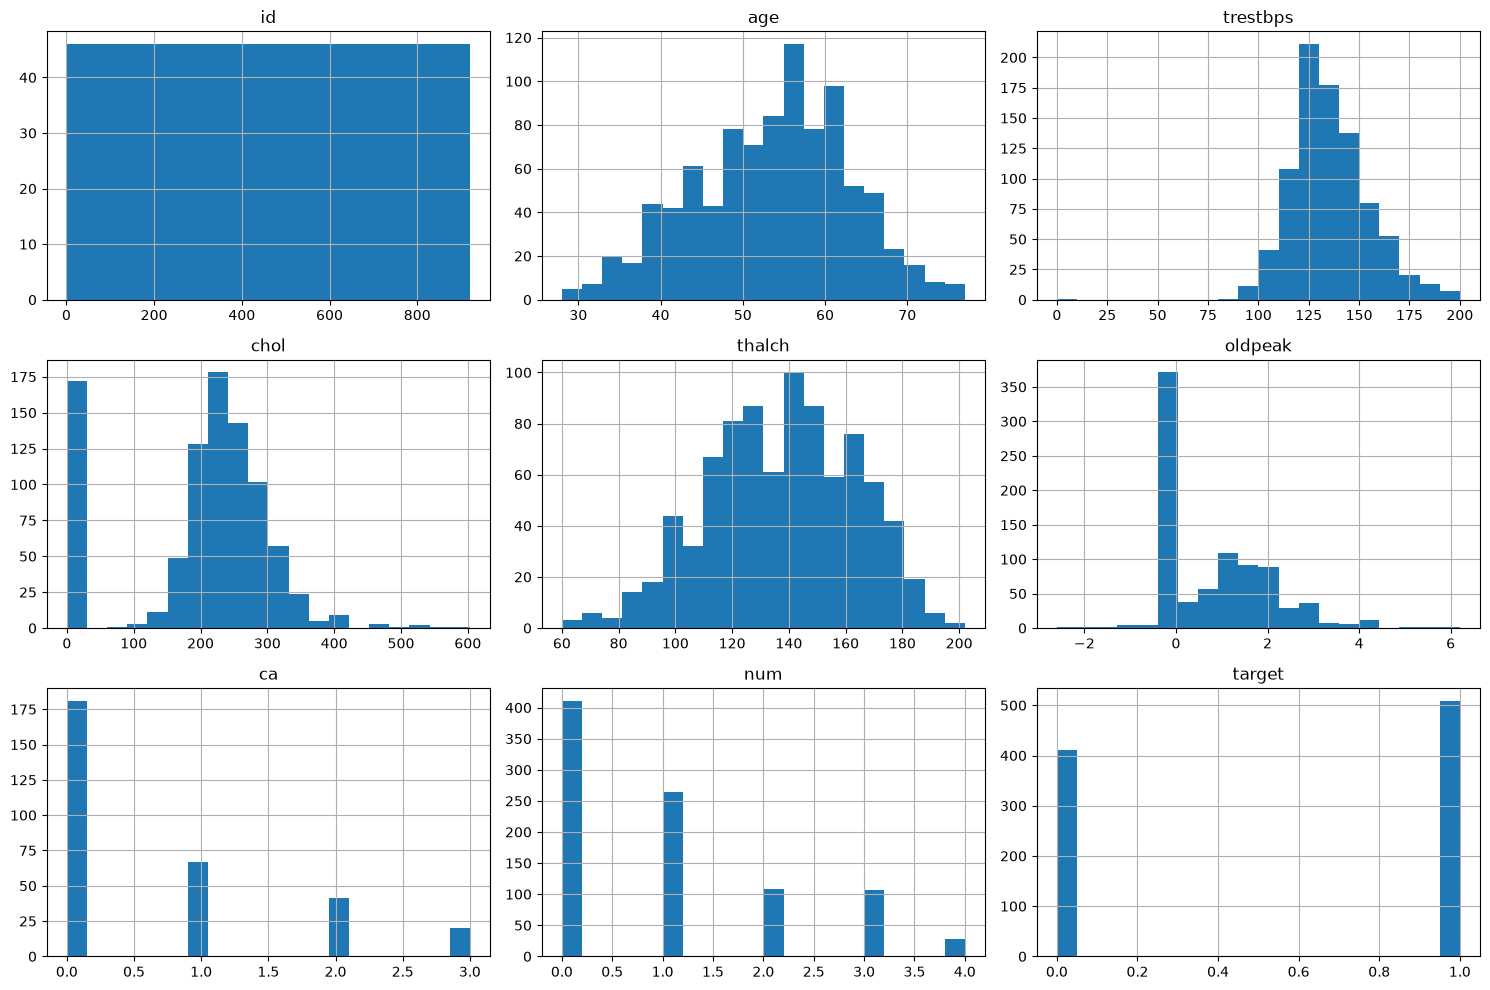

In [17]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_features.tolist())


df[numerical_features].hist(
    figsize=(15, 10),
    bins=20
)

plt.tight_layout()
plt.show()

## Solution for faults

### Dropping columns

In [18]:
drop_cols = ['id', 'dataset', 'num', 'ca', 'thal', 'slope']
df_clean = df.drop(columns=drop_cols)
print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'target']


### Impute: Categorial columns(boolean-like text)

In [19]:
def to_bool(x):
    if isinstance(x, str):
        return 1 if x.strip().lower() == 'true' else 0
    if isinstance(x, bool):
        return int(x)
    return x

df_clean['fbs'] = df_clean['fbs'].apply(to_bool)
df_clean['exang'] = df_clean['exang'].apply(to_bool)
print(df_clean[['fbs', 'exang']].head())

   fbs  exang
0  1.0    0.0
1  0.0    1.0
2  0.0    1.0
3  0.0    0.0
4  0.0    0.0


###Impute remaining missing values

In [20]:
num_impute_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for c in num_impute_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

cat_impute_cols = ['fbs', 'restecg', 'exang']
for c in cat_impute_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": (df_clean.isnull().sum() / len(df)) * 100
})

missing

Remaining missing values: 0


,Missing Values,Percentage
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalch,0,0.0
exang,0,0.0
oldpeak,0,0.0


### Encoded categorial variables(one hot encoding)

In [21]:
df_clean = pd.get_dummies(df_clean, columns=['sex', 'cp', 'restecg'], drop_first=True)

df_clean['fbs'] = df_clean['fbs'].astype(int)
df_clean['exang'] = df_clean['exang'].astype(int)

for c in df_clean.columns:
    if df_clean[c].dtype == bool:
        df_clean[c] = df_clean[c].astype(int)

print(df_clean.dtypes)
print("Final shape:", df_clean.shape)

age                           int64
trestbps                    float64
chol                        float64
fbs                           int64
thalch                      float64
exang                         int64
oldpeak                     float64
target                        int64
sex_Male                      int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_normal                int64
restecg_st-t abnormality      int64
dtype: object
Final shape: (920, 14)


###Final Features Count

In [22]:
X = df_clean.drop(columns=['target'])
y = df_clean['target']

feature_names = X.columns.tolist()
print("Number of final input features:", len(feature_names))
print("Features used:", feature_names)

Number of final input features: 13
Features used: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']


### Correlation heatmap of all input and output features

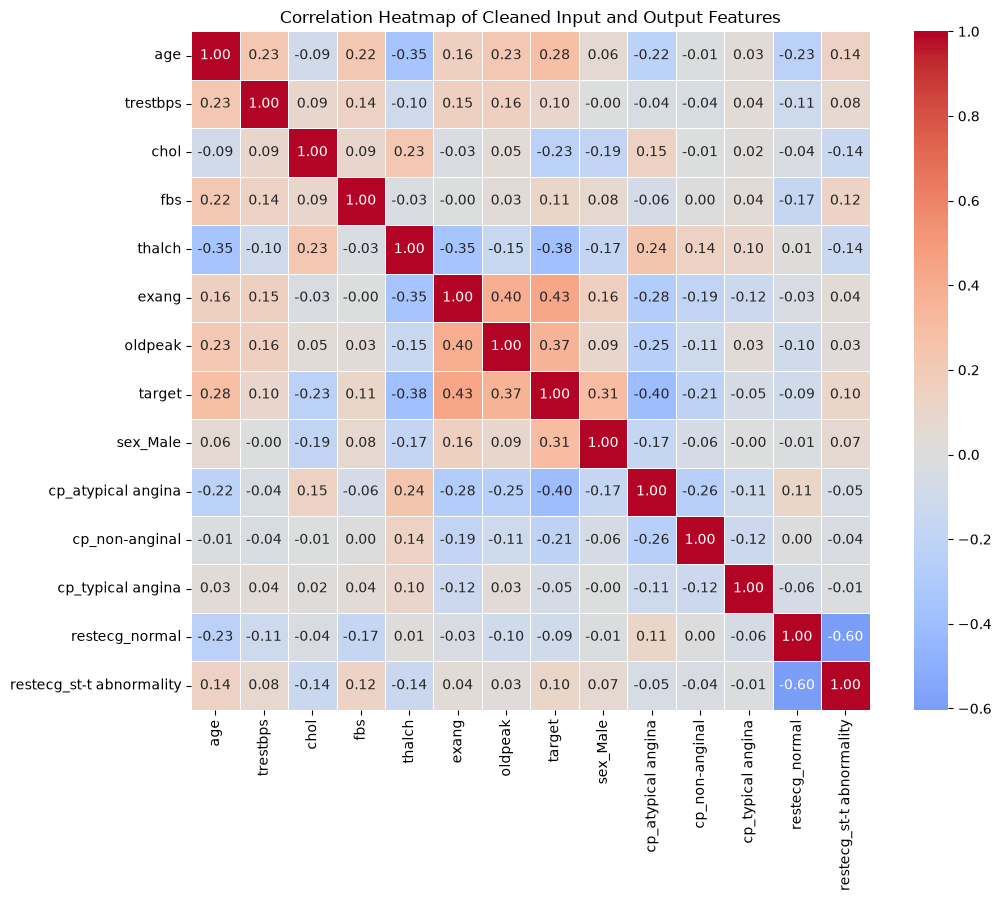

In [23]:
corr = df_clean.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Cleaned Input and Output Features")
plt.tight_layout()
plt.show()


## Dataset Splitting

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print()
print("Training set class balance:")
print(y_train.value_counts())
print()
print("Test set class balance:")
print(y_test.value_counts())

Training set size: 736
Test set size: 184

Training set class balance:
target
1    407
0    329
Name: count, dtype: int64

Test set class balance:
target
1    102
0     82
Name: count, dtype: int64


### Feature scaling

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. X_train_scaled shape:", X_train_scaled.shape)
print(X_train_scaled[:5])

Scaling complete. X_train_scaled shape: (736, 13)
[[-0.06314684  1.56027016 -1.85781647 -0.41469811 -0.62720514  1.3022944
  -0.80788285  0.5249412  -0.48252546  1.84585634 -0.23007121 -1.20894105
  -0.49745113]
 [ 2.1805258  -0.11641087 -1.85781647 -0.41469811  0.08762742 -0.76787553
  -0.33582682  0.5249412  -0.48252546  1.84585634 -0.23007121  0.82717019
  -0.49745113]
 [-0.06314684 -0.45174708  0.38262721 -0.41469811 -0.62720514  1.3022944
   1.08034128  0.5249412  -0.48252546 -0.54175397 -0.23007121  0.82717019
  -0.49745113]
 [ 0.79158559  0.44248281  0.05070963 -0.41469811  0.00820158  1.3022944
   0.98593007  0.5249412  -0.48252546 -0.54175397 -0.23007121 -1.20894105
  -0.49745113]
 [ 0.25737782  1.28082332 -1.85781647 -0.41469811 -1.5406023  -0.76787553
  -0.80788285  0.5249412  -0.48252546  1.84585634 -0.23007121 -1.20894105
   2.01024772]]


##Model Training and Testing (Supervised)

### Training Models

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000,
                                           random_state=42, early_stopping=True),
}

results = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "accuracy": acc, "precision": prec, "recall": rec,
        "auc": roc_auc, "confusion_matrix": cm.tolist()
    }
    roc_data[name] = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "auc": roc_auc}

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  AUC: {roc_auc:.4f}")
    print(cm)
    print()

=== Logistic Regression ===
Accuracy: 0.8261  Precision: 0.8182  Recall: 0.8824  AUC: 0.9071
[[62 20]
 [12 90]]

=== Naive Bayes ===
Accuracy: 0.8315  Precision: 0.8381  Recall: 0.8627  AUC: 0.8997
[[65 17]
 [14 88]]

=== Neural Network (MLP) ===
Accuracy: 0.8098  Precision: 0.7863  Recall: 0.9020  AUC: 0.9088
[[57 25]
 [10 92]]



###  Unsupervised Learning: Kmeans clustering

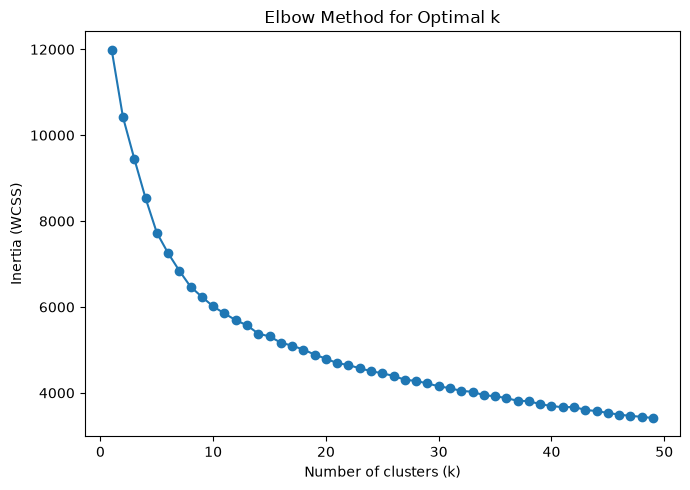

In [27]:
X_all = np.vstack([X_train_scaled, X_test_scaled])

# Elbow method to help choose k
inertias = []
K_range = range(1, 50)
fitted_models = {}   # store each fitted model so we don't refit later

for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    km.fit(X_all)
    inertias.append(km.inertia_)
    fitted_models[k_val] = km   # keep it around

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.show()

In [28]:
k = 5

kmeans = fitted_models[k]
cluster_labels = kmeans.labels_


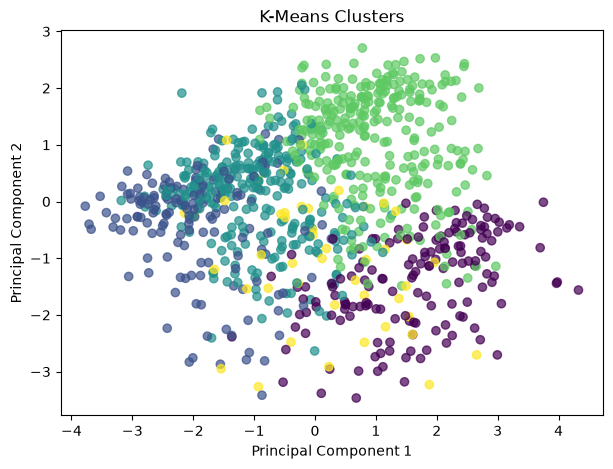

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()

## Model Selection/Comparison analysis

### Accuracy Comparison

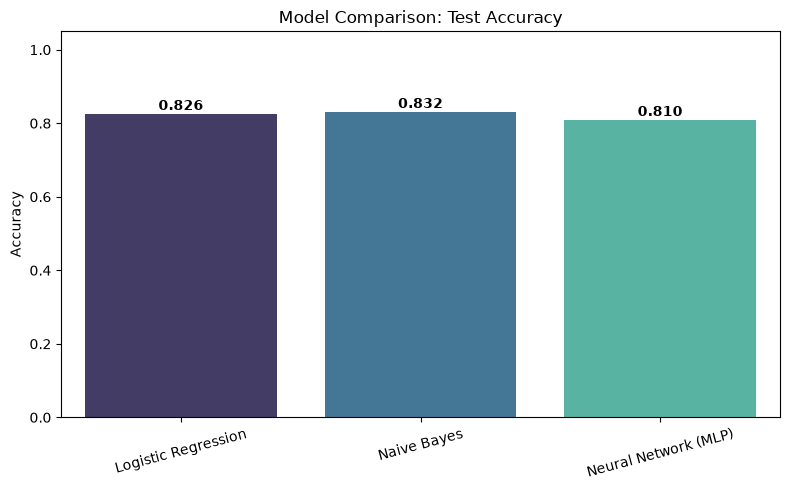

In [30]:
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=names, y=accs, hue=names, palette="mako", legend=False)
for i, v in enumerate(accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Model Comparison: Test Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Precision and Recall Comparison

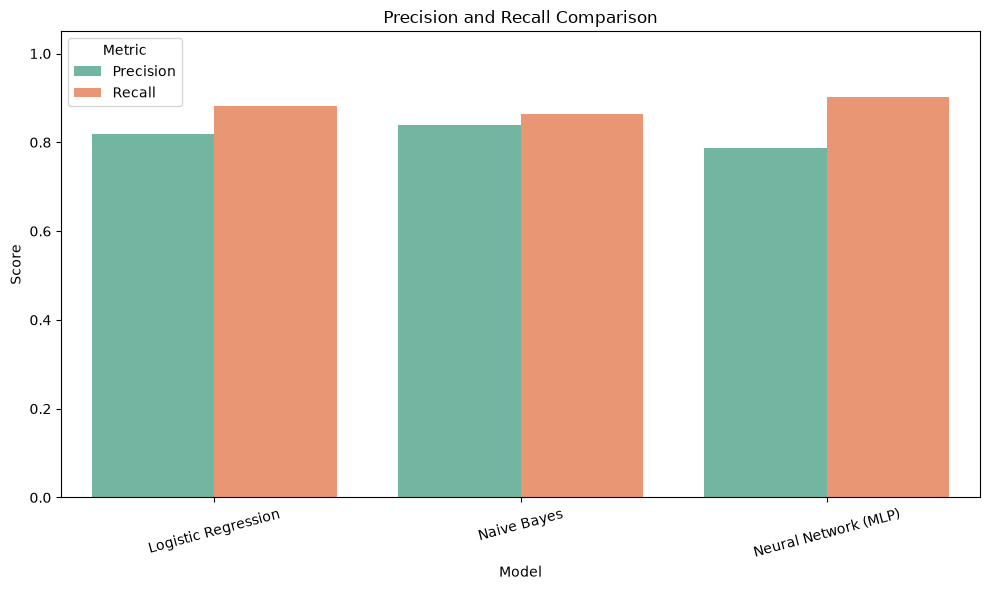

In [31]:
metrics_df = pd.DataFrame({
    "Model": names,
    "Precision": [results[n]['precision'] for n in names],
    "Recall": [results[n]['recall'] for n in names],

})
metrics_melt = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric", palette="Set2")
plt.ylim(0, 1.05)
plt.title("Precision and Recall Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Confusion Matrices

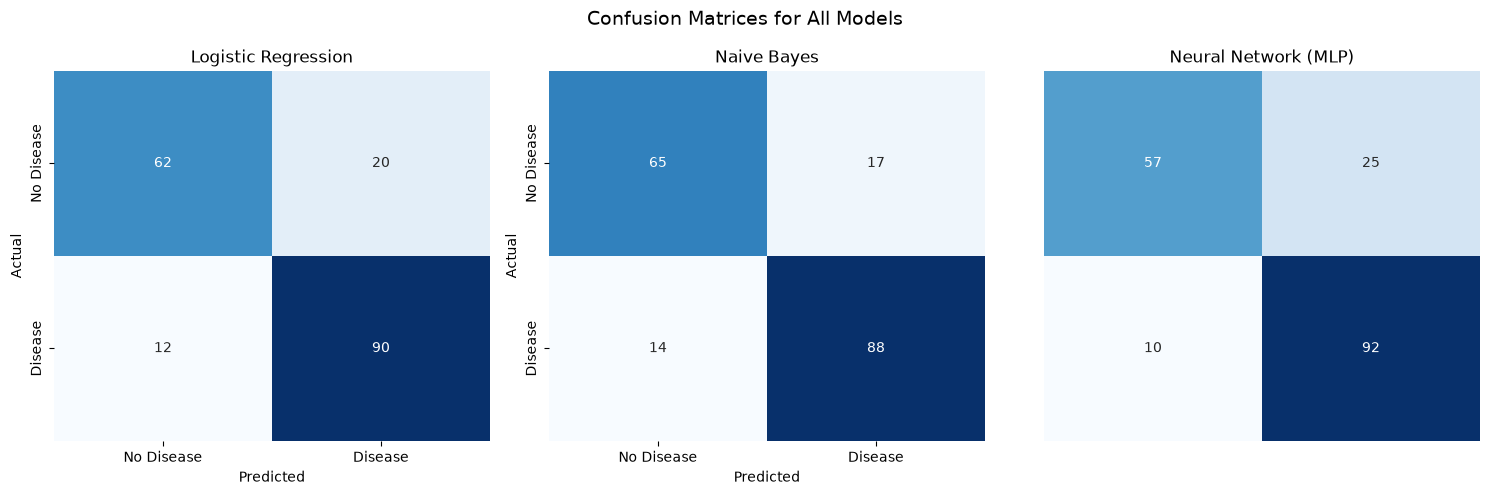

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for i, name in enumerate(names):
    cm = np.array(results[name]['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
axes[-1].axis('off')
plt.suptitle("Confusion Matrices for All Models", fontsize=14)
plt.tight_layout()
plt.show()

### AUC score, ROC curve for each model

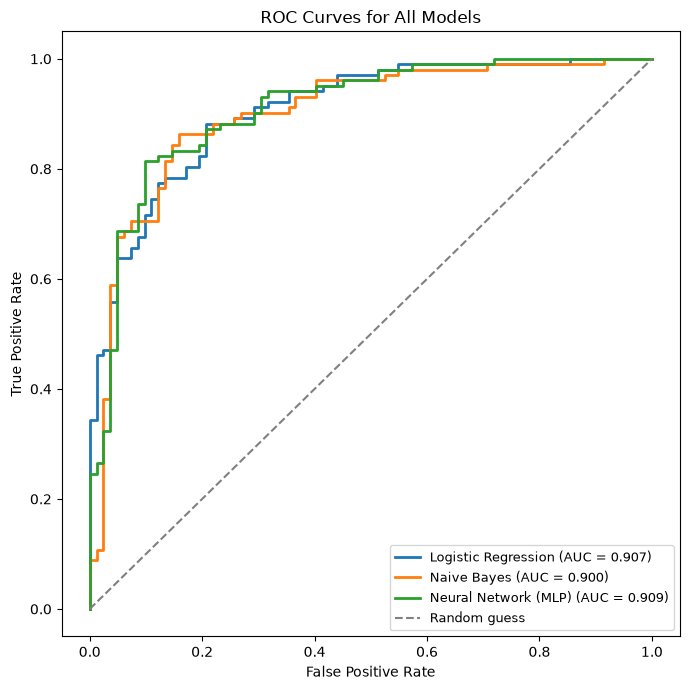

In [33]:
plt.figure(figsize=(7, 7))
for name in names:
    fpr = roc_data[name]['fpr']
    tpr = roc_data[name]['tpr']
    roc_auc = roc_data[name]['auc']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Summary Table

In [34]:
summary_df = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'auc']]
summary_df = summary_df.round(3)
summary_df

,accuracy,precision,recall,auc
Logistic Regression,0.826087,0.818182,0.882353,0.907102
Naive Bayes,0.831522,0.838095,0.862745,0.899689
Neural Network (MLP),0.809783,0.786325,0.901961,0.908776
